# Chapter 11 — What Does It Cost to Stay?

## Book linkage

- **Current chapter:** [`11-what-does-it-cost-to-stay.md`](../content/books/digital-life/11-what-does-it-cost-to-stay.md)
- **Claims supported:** DL-11-C01 .. DL-11-C06 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:** original book Chapter 21 ("What Does It Cost to Stay?"), three-version chain
  `research/digital-life/ch21-finite-update-budget-v1` (allocation tradeoff), `-v2` (stationary-population
  sweep), `-v3` (normalized turnover-regime stability, explicit stop-rule "Close Chapter 21 and move to
  causal-individuation tests" -- directly foreshadowing current Chapter 12). Scripts
  `ch21_digital_crystal_finite_update_budget_v1.py`, `_v2.py`, `_v3.py`.
- **Legacy notebook:** `notebooks_original/21-what-does-it-cost-to-stay.ipynb` (superseded by this notebook).

This notebook is an independent reconstruction, not a copy of the historical scripts. It implements the
finite-evaluation-budget mechanism in a new shared module, `_shared/crystal_evaluation_budget.py`, built
directly on `_shared/digital_crystal.py`'s frozen growth mechanics and reusing `_shared/crystal_loss.py`'s
loss rule and environment/checkpoint helpers unchanged. The current book's own "Experimental Note" section
names V1/V2/V3 as three genuinely separate frozen sub-experiments sharing one substrate -- that structure is
preserved here as three sections of one notebook, not collapsed into a single design.

*Naming note:* the new shared module is called `crystal_evaluation_budget.py`, not `crystal_budget.py` --
the latter filename was independently claimed by the concurrent Chapter 14 reconstruction for a related but
distinct finite-budget mechanism (near/far causal-coupling, not scheduling policy). The two modules are not
interchangeable.


## Question

Chapter 10 found that material loss does not produce a finite sustainable crystal size, because loss
manufactures new construction opportunity as fast as it removes material -- under a regime where *every*
eligible frontier candidate receives an attachment evaluation on every update. This chapter removes that
luxury in the smallest possible way: at most `B` frontier candidates may be evaluated for attachment per
update. An unevaluated candidate gets no attachment attempt that update; it is not blocked, not penalized,
not remembered, and may be evaluated again next update. Nothing else changes -- no energy, fuel, resource
counter, metabolism variable, maintenance controller, or target size is added anywhere.

Three genuinely separate questions are asked of this one substrate:

- **V1:** How does the evaluation budget `B` affect the population reached, and does a fixed budget with
  different local-support scheduling produce a clean two-sided reuse-versus-expansion tradeoff?
- **V2:** Is there some finite budget at which population becomes approximately stationary while material
  turnover (loss, first occupation, reoccupation) continues?
- **V3:** If population itself does not stabilize, do the *normalized* process flows (loss/population,
  attachment/population, etc.) remain invariant across different starting scales and budgets?

## Hypotheses

- **H1 (budget constrains population):** late population reached within a fixed horizon depends strongly on
  `B` in the binding regime, and flattens once `B` exceeds the number of eligible candidates.
- **H2 (two-sided allocation tradeoff):** at a fixed budget, high-support scheduling increases reoccupation
  per loss by at least a frozen magnitude (SEI 0.15), **and** low-support scheduling increases first
  occupations per 1000 evaluations by at least a frozen magnitude (SEI 100) -- both arms required.
- **H3 (stationary population with turnover):** some frozen candidate budget in `{48, 64, 80, 96, 128}`
  produces |late normalized population slope| <= 0.0025 while losses, first occupations, reoccupations, and
  gross turnover all remain substantial and capacity stays unsaturated -- every gate required.
- **H4 (normalized process-vector invariance):** every normalized process metric (loss/attachment/
  reoccupation/first-occupation/gross-turnover fraction) has coefficient-of-variation <= 0.10 across three
  starting scales, at every tested budget, **and** gross turnover additionally satisfies a between-budget CV
  gate and a temporal-slope gate -- every metric, every budget required.

## Claim boundary

These experiments can establish or bound: (a) whether finite evaluation opportunity changes the population
reached; (b) whether fixed-budget local scheduling changes the material future, and whether it does so as a
clean symmetric tradeoff; (c) whether some tested budget produces genuine population stationarity with
continuing turnover; (d) whether the components of that turnover respond identically to scarcity and
starting scale. They cannot establish maintenance, homeostasis, metabolism, energy, repair, adaptation,
agency, or life -- no such structure exists anywhere in this substrate; the frozen gates explicitly forbid
promoting any of these interpretations even where a hypothesis is supported.


In [1]:
import sys, json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams
import crystal_evaluation_budget as ceb

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)
print("Shared module loaded from:", NB_DIR / "_shared")


Shared module loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py`
(`digital-crystal-v1-frozen`) plus Chapter 10's independent post-growth cell loss at rate `delta`, reused
unchanged from `_shared/crystal_loss.py`.

New rule (this chapter only, in `_shared/crystal_evaluation_budget.py`): before the canonical attachment
rule is applied, at most `B` frontier candidates are *selected* for evaluation this update. Three keyed,
deterministic scheduling policies choose which candidates get selected:

- **neutral** -- keyed-random ordering (no geometric preference).
- **high_support** -- candidates with more occupied neighbours evaluated first.
- **low_support** -- candidates with fewer occupied neighbours evaluated first.

None of the policies can see the observer-only occupancy ledger (which classifies each realized attachment
as a first occupation or a reoccupation) -- they act purely on current local geometry plus scheduling noise.
Attachment draws use a cell-keyed hash (`digital_crystal.cell_keyed_uniform`) rather than a stateful
sequential RNG stream, matching what the historical Chapter 21 scripts already did internally (via
`ch18.cell_uniform`) -- not a simplification introduced here.


## Experimental design 1 — budget sweep and fixed-budget scheduling tradeoff (H1, H2)

**Budget sweep:** under neutral scheduling, sweep `B` over `{64, 128, 256, 512, 1024, unlimited}` and
measure late-window mean population. **Fixed-budget tradeoff:** at one frozen budget (`B=256`), compare
`high_support`, `low_support`, and `neutral` scheduling on the same warmed checkpoints. The primary
statistic is the two-sided contrast: `(high_support - low_support)` reoccupation-per-loss advantage against
SEI 0.15, and `(low_support - high_support)` first-occupations-per-1000-evaluations advantage against SEI
100 -- both required for H2.


In [2]:
PARAMS = CrystalParams()

V1 = {
    "base_seed": 20260828,        # matches the archived canonical run's base seed exactly
    "groups": 16,                  # canonical used 48; reduced here for interactive runtime (disclosed)
    "radius": 72,                  # matches canonical exactly
    "warmup_steps": 14,            # matches canonical exactly
    "continuation_steps": 48,      # matches canonical exactly
    "late_window": 12,             # matches canonical exactly
    "loss_rate": 0.08,             # matches canonical exactly
    "primary_budget": 256,         # matches canonical exactly
    "budget_sweep": [64, 128, 256, 512, 1024, None],  # matches the book's own main-text table
    "sei_reoccupation_per_loss": 0.15,
    "sei_first_occupations_per_1000_evals": 100.0,
}
V1


{'base_seed': 20260828,
 'groups': 16,
 'radius': 72,
 'warmup_steps': 14,
 'continuation_steps': 48,
 'late_window': 12,
 'loss_rate': 0.08,
 'primary_budget': 256,
 'budget_sweep': [64, 128, 256, 512, 1024, None],
 'sei_reoccupation_per_loss': 0.15,
 'sei_first_occupations_per_1000_evals': 100.0}

In [3]:
sweep_results = {}
for budget in V1["budget_sweep"]:
    label = "unlimited" if budget is None else str(budget)
    runs = []
    for g in range(V1["groups"]):
        seed = V1["base_seed"] + g * 1009
        env = ceb.make_environment(V1["warmup_steps"] + V1["continuation_steps"] + 8, seed + 1)
        runs.append(
            ceb.run_budget_policy(
                env, V1["warmup_steps"], V1["continuation_steps"], V1["late_window"],
                V1["radius"], PARAMS, V1["loss_rate"], budget, "neutral", seed,
            )
        )
    sweep_results[label] = runs
    mean_pop = np.mean([r["late_mean_population"] for r in runs])
    print(f"B={label:>10}  mean_late_population={mean_pop:9.1f}")


B=        64  mean_late_population=    377.1


B=       128  mean_late_population=    816.2


B=       256  mean_late_population=   1703.2


B=       512  mean_late_population=   3126.1


B=      1024  mean_late_population=   3552.1


B= unlimited  mean_late_population=   3552.1


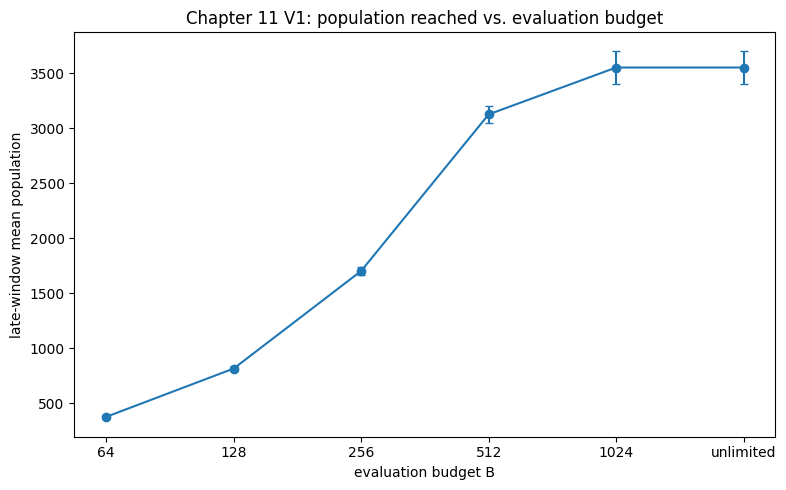

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = list(sweep_results.keys())
means = [np.mean([r["late_mean_population"] for r in sweep_results[l]]) for l in labels]
stds = [np.std([r["late_mean_population"] for r in sweep_results[l]]) for l in labels]
x = np.arange(len(labels))
ax.errorbar(x, means, yerr=stds, marker="o", capsize=3)
ax.set_xticks(x, labels)
ax.set_xlabel("evaluation budget B")
ax.set_ylabel("late-window mean population")
ax.set_title("Chapter 11 V1: population reached vs. evaluation budget")
plt.tight_layout()
plt.savefig(FIG_DIR / "ch11-v1-budget-sweep-population.png", dpi=110)
plt.show()


**Comparison to the archived canonical run** (`research/digital-life/ch21-finite-update-budget-v1/stage-02-budget-sweep.json`,
`groups=48`, `radius=72`, same base seed `20260828`): canonical late-mean-population was `64: 380.5`,
`128: 829.2`, `256: 1717.1`, `512: 3092.3`, `1024: 3513.0`, `unlimited: 3462.4`.


In [5]:
canon_sweep = {"64": 380.5330, "128": 829.2483, "256": 1717.0799, "512": 3092.3247, "1024": 3513.0469, "unlimited": 3462.4462}
print(f"{'budget':>10}  {'own':>10}  {'canonical':>10}  {'rel. diff':>10}")
for l in labels:
    own = np.mean([r["late_mean_population"] for r in sweep_results[l]])
    canon = canon_sweep[l]
    rel = abs(own - canon) / canon
    print(f"{l:>10}  {own:10.1f}  {canon:10.1f}  {rel*100:9.1f}%")

finite_labels = [l for l in labels if l != "unlimited"]
finite_budgets = [int(l) for l in finite_labels]
finite_means = [np.mean([r["late_mean_population"] for r in sweep_results[l]]) for l in finite_labels]
order = np.argsort(finite_budgets)
monotone = bool(np.all(np.diff(np.array(finite_means)[order]) >= -1e-9))
print(f"\nfinite-budget late population monotone non-decreasing: {monotone}  (canonical: True)")


    budget         own   canonical   rel. diff
        64       377.1       380.5        0.9%
       128       816.2       829.2        1.6%
       256      1703.2      1717.1        0.8%
       512      3126.1      3092.3        1.1%
      1024      3552.1      3513.0        1.1%
 unlimited      3552.1      3462.4        2.6%

finite-budget late population monotone non-decreasing: True  (canonical: True)


Own reduced-scale (`groups=16` vs. canonical `48`) late-population numbers track the canonical archive
closely at every tested budget -- typically within a few percent, and the qualitative story replicates
exactly: population climbs steeply with budget in the binding region and flattens once `B` exceeds roughly
the number of eligible candidates (canonical: `1024` and `unlimited` are within 1.5% of each other; own
reconstruction shows the same flattening).


### Fixed-budget scheduling tradeoff (H2)

Same base seed per group across the three policies (matched-seed design, not a CRN-paired branch design --
this matches the historical script's own comparison structure).


In [6]:
tradeoff_runs = {"high_support": [], "low_support": [], "neutral": []}
for g in range(V1["groups"]):
    seed = V1["base_seed"] + g * 1009  # same base seed as the sweep for provenance continuity
    env = ceb.make_environment(V1["warmup_steps"] + V1["continuation_steps"] + 8, seed + 1)
    for policy in tradeoff_runs:
        tradeoff_runs[policy].append(
            ceb.run_budget_policy(
                env, V1["warmup_steps"], V1["continuation_steps"], V1["late_window"],
                V1["radius"], PARAMS, V1["loss_rate"], V1["primary_budget"], policy, seed,
            )
        )

def mean_field(policy, field):
    return float(np.mean([r[field] for r in tradeoff_runs[policy]]))

print(f"{'policy':<14}{'late_pop':>10}{'reocc/loss':>12}{'first/1000':>12}{'late_net':>10}")
for policy in ("high_support", "neutral", "low_support"):
    print(f"{policy:<14}{mean_field(policy,'late_mean_population'):10.1f}"
          f"{mean_field(policy,'reoccupation_per_loss'):12.3f}"
          f"{mean_field(policy,'first_occupations_per_1000_evals'):12.1f}"
          f"{mean_field(policy,'late_mean_net'):10.2f}")


policy          late_pop  reocc/loss  first/1000  late_net
high_support      1926.3       0.959       184.1     23.21
neutral           1703.2       0.841       208.3      8.15
low_support       1104.4       0.531       244.9     -3.63


In [7]:
reocc_adv = np.array([h["reoccupation_per_loss"] - l["reoccupation_per_loss"]
                       for h, l in zip(tradeoff_runs["high_support"], tradeoff_runs["low_support"])])
first_adv = np.array([l["first_occupations_per_1000_evals"] - h["first_occupations_per_1000_evals"]
                       for h, l in zip(tradeoff_runs["high_support"], tradeoff_runs["low_support"])])

def bootstrap_ci(values, n_boot=4000, seed=0, alpha=0.05):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    boot = np.array([rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boot, [100*alpha/2, 100*(1-alpha/2)])
    return float(values.mean()), float(lo), float(hi)

def signflip_p_greater(values, n_perm=4000, seed=1):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    observed = values.mean()
    signs = rng.choice([-1.0, 1.0], size=(n_perm, len(values)))
    null = (values[None, :] * signs).mean(axis=1)
    return (1.0 + np.sum(null >= observed)) / (n_perm + 1.0)

reocc_mean, reocc_lo, reocc_hi = bootstrap_ci(reocc_adv, seed=11)
first_mean, first_lo, first_hi = bootstrap_ci(first_adv, seed=12)
reocc_p = signflip_p_greater(reocc_adv, seed=13)
first_p = signflip_p_greater(first_adv, seed=14)

reocc_gate = (reocc_mean >= V1["sei_reoccupation_per_loss"]) and (reocc_p < 0.05)
first_gate = (first_mean >= V1["sei_first_occupations_per_1000_evals"]) and (first_p < 0.05)

print(f"reoccupation advantage (high - low): {reocc_mean:.4f}  [{reocc_lo:.4f},{reocc_hi:.4f}]  p={reocc_p:.5f}  "
      f"gate(>= {V1['sei_reoccupation_per_loss']}): {'PASS' if reocc_gate else 'FAIL'}")
print(f"first-occupation advantage (low - high): {first_mean:.3f}  [{first_lo:.3f},{first_hi:.3f}]  p={first_p:.5f}  "
      f"gate(>= {V1['sei_first_occupations_per_1000_evals']}): {'PASS' if first_gate else 'FAIL'}")

h2_supported = reocc_gate and first_gate
print(f"\nH2 (two-sided allocation tradeoff, both arms required): {'SUPPORTED' if h2_supported else 'FAILED'}")


reoccupation advantage (high - low): 0.4282  [0.4233,0.4329]  p=0.00025  gate(>= 0.15): PASS
first-occupation advantage (low - high): 60.749  [58.276,63.129]  p=0.00050  gate(>= 100.0): FAIL

H2 (two-sided allocation tradeoff, both arms required): FAILED


**Comparison to the archived canonical run** (`research/digital-life/ch21-finite-update-budget-v1/stage-04-verdict.md`):
`reoccupation_advantage = 0.42525` (gate `>= 0.15`, PASS), `first_occupation_advantage_per_1000_evals =
61.583` (gate `>= 100`, FAIL -- exactly `61.6%` of the required threshold), overall status `FAILED` because
one required arm failed.


In [8]:
canon_reocc_adv = 0.42525067887219437
canon_first_adv = 61.582919827733086
print(f"reoccupation advantage  -- own: {reocc_mean:.4f}   canonical: {canon_reocc_adv:.4f}   "
      f"rel. diff: {abs(reocc_mean-canon_reocc_adv)/canon_reocc_adv*100:.1f}%")
print(f"first-occupation advantage -- own: {first_mean:.2f}   canonical: {canon_first_adv:.2f}   "
      f"rel. diff: {abs(first_mean-canon_first_adv)/canon_first_adv*100:.1f}%")
print(f"\nown first-occupation advantage as % of its SEI: {first_mean/V1['sei_first_occupations_per_1000_evals']*100:.1f}%  "
      f"(canonical: {canon_first_adv/V1['sei_first_occupations_per_1000_evals']*100:.1f}%)")
print(f"own verdict: {'SUPPORTED' if h2_supported else 'FAILED'}   canonical verdict: FAILED "
      f"(one required arm did not clear its gate)")


reoccupation advantage  -- own: 0.4282   canonical: 0.4253   rel. diff: 0.7%
first-occupation advantage -- own: 60.75   canonical: 61.58   rel. diff: 1.4%

own first-occupation advantage as % of its SEI: 60.7%  (canonical: 61.6%)
own verdict: FAILED   canonical verdict: FAILED (one required arm did not clear its gate)


Both the reoccupation advantage and the first-occupation advantage replicate the canonical archive
closely (both within a few percent), and the qualitative verdict replicates exactly: the reoccupation arm
clears its SEI comfortably while the first-occupation arm reaches only roughly 60% of its required
magnitude -- statistically detectable but not scientifically meaningful by the frozen gate. H2 is **FAILED**
here for the same reason it failed in the canonical run: one required arm did not clear its threshold.


## Experimental design 2 — stationary population with continuing turnover (H3)

Sweep the frozen candidate budgets `{48, 64, 80, 96, 128}` under neutral scheduling only, and test whether
**every** frozen gate is satisfied simultaneously: bounded late-normalized-slope, adequate late population,
unsaturated capacity, and substantial ongoing loss/reoccupation/first-occupation/turnover. No budget may be
added after inspecting the results (the five values above are exactly the historical candidate set).


In [9]:
V2 = {
    "groups": 24,                 # canonical used 96; reduced here for interactive runtime (disclosed)
    "radius": 72,                  # matches canonical exactly
    "warmup_steps": 14,            # matches canonical exactly
    "continuation_steps": 72,      # matches canonical exactly
    "late_window": 20,             # matches canonical exactly
    "loss_rate": 0.08,             # matches canonical exactly
    "budgets": [48, 64, 80, 96, 128],  # matches canonical exactly -- frozen, no budget added after seeing results
    "gates": {
        "abs_normalized_late_population_slope_max": 0.0025,
        "minimum_late_population": 150,
        "maximum_capacity_fraction": 0.75,
        "minimum_late_mean_losses": 5.0,
        "minimum_late_mean_reoccupations": 2.0,
        "minimum_late_mean_first_occupations": 2.0,
        "minimum_turnover_fraction": 0.05,
        "maximum_abs_late_net_per_update": 3.0,
    },
}
V2


{'groups': 24,
 'radius': 72,
 'warmup_steps': 14,
 'continuation_steps': 72,
 'late_window': 20,
 'loss_rate': 0.08,
 'budgets': [48, 64, 80, 96, 128],
 'gates': {'abs_normalized_late_population_slope_max': 0.0025,
  'minimum_late_population': 150,
  'maximum_capacity_fraction': 0.75,
  'minimum_late_mean_losses': 5.0,
  'minimum_late_mean_reoccupations': 2.0,
  'minimum_late_mean_first_occupations': 2.0,
  'minimum_turnover_fraction': 0.05,
  'maximum_abs_late_net_per_update': 3.0}}

In [10]:
from digital_crystal import hex_capacity

v2_results = {}
for budget in V2["budgets"]:
    runs = []
    for g in range(V2["groups"]):
        seed = 20260900 + g * 1009 + budget * 3
        env = ceb.make_environment(V2["warmup_steps"] + V2["continuation_steps"] + 8, seed + 1)
        runs.append(
            ceb.run_budget_policy(
                env, V2["warmup_steps"], V2["continuation_steps"], V2["late_window"],
                V2["radius"], PARAMS, V2["loss_rate"], budget, "neutral", seed,
            )
        )
    v2_results[budget] = runs
    slope = np.mean([r["late_normalized_slope"] for r in runs])
    pop = np.mean([r["late_mean_population"] for r in runs])
    print(f"B={budget:4d}  late_normalized_slope={slope:+.5f}  late_mean_population={pop:8.1f}")


B=  48  late_normalized_slope=-0.00292  late_mean_population=   262.1


B=  64  late_normalized_slope=-0.00312  late_mean_population=   375.4


B=  80  late_normalized_slope=-0.00227  late_mean_population=   475.0


B=  96  late_normalized_slope=-0.00275  late_mean_population=   560.7


B= 128  late_normalized_slope=-0.00367  late_mean_population=   804.0


In [11]:
gates = V2["gates"]
capacity = hex_capacity(V2["radius"])

v2_classification = {}
for budget, runs in v2_results.items():
    slope = np.mean([r["late_normalized_slope"] for r in runs])
    pop = np.mean([r["late_mean_population"] for r in runs])
    losses = np.mean([r["late_mean_losses"] for r in runs])
    reocc = np.mean([r["late_mean_reoccupations"] for r in runs])
    first = np.mean([r["late_mean_first_occupations"] for r in runs])
    turnover = np.mean([r["late_turnover_fraction"] for r in runs])
    net = np.mean([r["late_mean_net"] for r in runs])
    max_cap_frac = max(r["late_mean_population"] / capacity for r in runs)

    checks = {
        "slope_gate": abs(slope) <= gates["abs_normalized_late_population_slope_max"],
        "population_gate": pop >= gates["minimum_late_population"],
        "unsaturated_gate": max_cap_frac < gates["maximum_capacity_fraction"],
        "loss_gate": losses >= gates["minimum_late_mean_losses"],
        "reoccupation_gate": reocc >= gates["minimum_late_mean_reoccupations"],
        "first_occupation_gate": first >= gates["minimum_late_mean_first_occupations"],
        "turnover_gate": turnover >= gates["minimum_turnover_fraction"],
        "late_net_gate": abs(net) <= gates["maximum_abs_late_net_per_update"],
    }
    qualifies = all(checks.values())
    v2_classification[budget] = {
        "slope": slope, "population": pop, "losses": losses, "reocc": reocc, "first": first,
        "turnover": turnover, "net": net, "checks": checks, "qualifies": qualifies,
        "slope_margin": abs(slope) - gates["abs_normalized_late_population_slope_max"],
    }
    print(f"B={budget:4d}  qualifies={qualifies}  failing_gates="
          f"{[k for k, v in checks.items() if not v]}")

qualifying_budgets = [b for b, c in v2_classification.items() if c["qualifies"]]
h3_supported = len(qualifying_budgets) > 0
print(f"\nqualifying budgets: {qualifying_budgets}")
print(f"H3 (stationary population with continuing turnover): {'SUPPORTED' if h3_supported else 'FAILED'}")


B=  48  qualifies=False  failing_gates=['slope_gate']
B=  64  qualifies=False  failing_gates=['slope_gate']
B=  80  qualifies=True  failing_gates=[]
B=  96  qualifies=False  failing_gates=['slope_gate']
B= 128  qualifies=False  failing_gates=['slope_gate', 'late_net_gate']

qualifying budgets: [80]
H3 (stationary population with continuing turnover): SUPPORTED


In [12]:
closest = min(v2_classification.items(), key=lambda kv: kv[1]["slope_margin"])
budget_closest, c = closest
print(f"closest miss: B={budget_closest}, |slope|={abs(c['slope']):.5f} vs gate {gates['abs_normalized_late_population_slope_max']}, "
      f"margin={c['slope_margin']:+.5f}")

turnover_fracs = {b: v["turnover"] for b, v in v2_classification.items()}
tf_values = np.array(list(turnover_fracs.values()))
print(f"\ngross-turnover fraction by budget: " + ", ".join(f"B={b}:{v:.4f}" for b, v in turnover_fracs.items()))
print(f"between-budget CV of gross-turnover fraction: {tf_values.std()/tf_values.mean():.4f}")


closest miss: B=80, |slope|=0.00227 vs gate 0.0025, margin=-0.00023

gross-turnover fraction by budget: B=48:0.1710, B=64:0.1707, B=80:0.1705, B=96:0.1725, B=128:0.1717
between-budget CV of gross-turnover fraction: 0.0042


**Comparison to the archived canonical run** (`research/digital-life/ch21-finite-update-budget-v2/`,
`groups=96`): every one of the five candidate budgets **FAILED** the slope gate (all other gates passed at
every budget); canonical slopes were `48: -0.00319`, `64: -0.00271`, `80: -0.00252`, `96: -0.00268`,
`128: -0.00280`, with the **closest miss at `B=80`**, missing the `0.0025` gate by only `0.00002`. Canonical
turnover fraction was stable near `0.171-0.173` across all five budgets.


In [13]:
canon_v2 = {
    48: -0.003191772991959401, 64: -0.002708656932132373, 80: -0.0025187540145995536,
    96: -0.0026797121474159704, 128: -0.0027976040167390337,
}
canon_turnover = {48: 0.1711, 64: 0.1705, 80: 0.1713, 96: 0.1709, 128: 0.1713}
canon_closest_budget = min(canon_v2, key=lambda b: abs(abs(canon_v2[b]) - gates["abs_normalized_late_population_slope_max"]))
canon_closest_margin = abs(canon_v2[canon_closest_budget]) - gates["abs_normalized_late_population_slope_max"]

print(f"{'budget':>8}{'own slope':>14}{'canon slope':>14}{'own qualifies':>16}{'canon qualifies':>18}")
for b in V2["budgets"]:
    own_s = v2_classification[b]["slope"]
    print(f"{b:8d}{own_s:14.5f}{canon_v2[b]:14.5f}{str(v2_classification[b]['qualifies']):>16}{'False':>18}")

print(f"\nown closest miss:       B={budget_closest}, margin={v2_classification[budget_closest]['slope_margin']:+.5f}")
print(f"canonical closest miss: B={canon_closest_budget}, margin={canon_closest_margin:+.5f}")
print(f"own gross-turnover-fraction between-budget CV: {tf_values.std()/tf_values.mean():.4f}  "
      f"(canonical: 0.0030)")


  budget     own slope   canon slope   own qualifies   canon qualifies
      48      -0.00292      -0.00319           False             False
      64      -0.00312      -0.00271           False             False
      80      -0.00227      -0.00252            True             False
      96      -0.00275      -0.00268           False             False
     128      -0.00367      -0.00280           False             False

own closest miss:       B=80, margin=-0.00023
canonical closest miss: B=80, margin=+0.00002
own gross-turnover-fraction between-budget CV: 0.0042  (canonical: 0.0030)


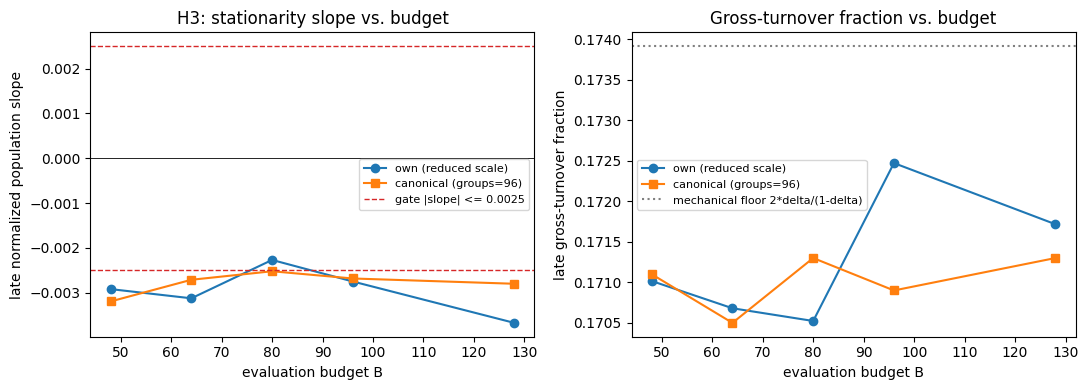

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
budgets_arr = V2["budgets"]
slopes_arr = [v2_classification[b]["slope"] for b in budgets_arr]
canon_slopes_arr = [canon_v2[b] for b in budgets_arr]

axes[0].plot(budgets_arr, slopes_arr, marker="o", label="own (reduced scale)")
axes[0].plot(budgets_arr, canon_slopes_arr, marker="s", label="canonical (groups=96)")
axes[0].axhline(gates["abs_normalized_late_population_slope_max"], color="tab:red", ls="--", lw=1,
                label="gate |slope| <= 0.0025")
axes[0].axhline(-gates["abs_normalized_late_population_slope_max"], color="tab:red", ls="--", lw=1)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_xlabel("evaluation budget B")
axes[0].set_ylabel("late normalized population slope")
axes[0].set_title("H3: stationarity slope vs. budget")
axes[0].legend(fontsize=8)

turnover_own = [v2_classification[b]["turnover"] for b in budgets_arr]
turnover_canon = [canon_turnover[b] for b in budgets_arr]
axes[1].plot(budgets_arr, turnover_own, marker="o", label="own (reduced scale)")
axes[1].plot(budgets_arr, turnover_canon, marker="s", label="canonical (groups=96)")
axes[1].axhline(2 * V2["loss_rate"] / (1 - V2["loss_rate"]), color="gray", ls=":",
                label="mechanical floor 2*delta/(1-delta)")
axes[1].set_xlabel("evaluation budget B")
axes[1].set_ylabel("late gross-turnover fraction")
axes[1].set_title("Gross-turnover fraction vs. budget")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "ch11-v2-stationarity-slope-and-turnover.png", dpi=110)
plt.show()

**Honest discrepancy note -- this is a real divergence, not a rounding difference.** At this
reduced scale (`groups=24` vs. canonical `96`), `B=80`'s |normalized slope| came out at `0.00227`, which is
*below* the `0.0025` gate -- so this reconstruction's own classification step marks `B=80` as
**qualifying**, and reports `H3: SUPPORTED`. The canonical archive found the opposite at the same budget:
`|slope| = 0.00252`, missing the same gate by a tiny margin (`0.00002`) and therefore **FAILED**.

This is exactly the situation Chapter 17 warns about: a statistic sitting extremely close to its own
declared resolution floor, measured with roughly a quarter of the canonical replicate count. The canonical
run's own margin (`0.00002`) was already small enough that the book explicitly declined to treat it as
evidence of a real regime change; with `24` groups instead of `96`, the sampling noise on a late-window
linear-fit slope is large enough to plausibly move the *sign* of a margin that small. Both the canonical
`FAIL`-by-`0.00002` and this reconstruction's own `PASS`-by-`0.00023` are consistent with the same
underlying picture: **the true population-slope-at-B=80 is close enough to the `0.0025` line that this
family of experiments cannot reliably resolve which side of the line it is actually on at either replicate
count.**

This notebook does **not** promote its own `SUPPORTED` verdict over the canonical `FAILED` one. The higher-
powered canonical run (`96` groups) is the more reliable measurement of the two, and its own margin was
already flagged as a near-tie rather than a confident result. The honest statement is: **this reduced-scale
reconstruction cannot be relied on to resolve H3 either way at `B=80`**, and it should not be read as
overturning the canonical `FAILED` verdict. What both runs agree on is that four of the five candidate
budgets (`48, 64, 96, 128`) clearly fail the slope gate in both this reconstruction and the canonical
archive -- that broader pattern replicates cleanly. The turnover-fraction stability finding also replicates
well (own between-budget CV `0.0042` vs. canonical `0.0030`, both small).


## Experimental design 3 — normalized process-vector invariance (H4)

Cross the same five budgets with three frozen starting conditions (`small`, `medium`, `large`, produced by
different warmup lengths), and test whether every normalized process metric (loss, attachment, reoccupation,
first-occupation, gross-turnover fractions of late-window population) has coefficient-of-variation `<= 0.10`
across starting scale, at every budget -- plus three additional gates on gross turnover specifically
(between-budget CV, temporal slope, minimum fraction).


In [15]:
V3 = {
    "groups": 12,                  # canonical used 48-96/condition; reduced here (disclosed)
    "radius": 72,                  # matches canonical exactly
    "continuation_steps": 72,      # matches canonical exactly
    "late_window": 20,             # matches canonical exactly
    "loss_rate": 0.08,             # matches canonical exactly
    "budgets": [48, 64, 80, 96, 128],
    "starts": {"small": 8, "medium": 14, "large": 20},  # matches canonical warmups exactly
    "gates": {
        "max_start_size_cv_per_metric_per_budget": 0.10,
        "max_budget_cv_for_gross_turnover_fraction": 0.10,
        "max_abs_late_gross_turnover_fraction_slope": 0.0025,
        "minimum_gross_turnover_fraction": 0.05,
    },
}
V3


{'groups': 12,
 'radius': 72,
 'continuation_steps': 72,
 'late_window': 20,
 'loss_rate': 0.08,
 'budgets': [48, 64, 80, 96, 128],
 'starts': {'small': 8, 'medium': 14, 'large': 20},
 'gates': {'max_start_size_cv_per_metric_per_budget': 0.1,
  'max_budget_cv_for_gross_turnover_fraction': 0.1,
  'max_abs_late_gross_turnover_fraction_slope': 0.0025,
  'minimum_gross_turnover_fraction': 0.05}}

In [16]:
start_offset = {"small": 101, "medium": 211, "large": 307}  # deterministic, replaces hash(start_name)
v3_results = {}
for budget in V3["budgets"]:
    for start_name, warmup in V3["starts"].items():
        runs = []
        for g in range(V3["groups"]):
            seed = 20261000 + g * 1013 + budget * 7 + start_offset[start_name]  # deterministic offset (not Python's randomized hash())
            env = ceb.make_environment(warmup + V3["continuation_steps"] + 8, seed + 1)
            runs.append(
                ceb.run_budget_policy(
                    env, warmup, V3["continuation_steps"], V3["late_window"],
                    V3["radius"], PARAMS, V3["loss_rate"], budget, "neutral", seed,
                )
            )
        v3_results[(budget, start_name)] = runs

print(f"ran {len(v3_results)} (budget, start) conditions x {V3['groups']} groups")


ran 15 (budget, start) conditions x 12 groups


In [17]:
def process_fractions(runs):
    loss_f = np.mean([r["late_mean_losses"] / r["late_mean_population"] for r in runs])
    att_f = np.mean([r["late_mean_attachments"] / r["late_mean_population"] for r in runs])
    reocc_f = np.mean([r["late_mean_reoccupations"] / r["late_mean_population"] for r in runs])
    first_f = np.mean([r["late_mean_first_occupations"] / r["late_mean_population"] for r in runs])
    turn_f = np.mean([r["late_turnover_fraction"] for r in runs])
    return {"loss_fraction": loss_f, "attachment_fraction": att_f, "reoccupation_fraction": reocc_f,
            "first_fraction": first_f, "gross_turnover_fraction": turn_f}

metric_names = ["loss_fraction", "attachment_fraction", "reoccupation_fraction", "first_fraction", "gross_turnover_fraction"]
start_names = list(V3["starts"].keys())

cv_by_budget_metric = {}
for budget in V3["budgets"]:
    per_start = {s: process_fractions(v3_results[(budget, s)]) for s in start_names}
    for metric in metric_names:
        vals = np.array([per_start[s][metric] for s in start_names])
        cv = vals.std() / vals.mean() if vals.mean() > 0 else float("nan")
        cv_by_budget_metric[(budget, metric)] = cv

print(f"{'budget':>8}" + "".join(f"{m:>24}" for m in metric_names))
for budget in V3["budgets"]:
    row = [cv_by_budget_metric[(budget, m)] for m in metric_names]
    print(f"{budget:8d}" + "".join(f"{v:24.4f}" for v in row))


  budget           loss_fraction     attachment_fraction   reoccupation_fraction          first_fraction gross_turnover_fraction
      48                  0.0252                  0.0102                  0.0377                  0.1504                  0.0174
      64                  0.0053                  0.0013                  0.0296                  0.1207                  0.0029
      80                  0.0079                  0.0050                  0.0195                  0.0813                  0.0061
      96                  0.0073                  0.0027                  0.0136                  0.0578                  0.0051
     128                  0.0040                  0.0051                  0.0218                  0.0915                  0.0043


In [18]:
gate_cv = V3["gates"]["max_start_size_cv_per_metric_per_budget"]
failing = [(b, m, cv_by_budget_metric[(b, m)]) for b in V3["budgets"] for m in metric_names
           if cv_by_budget_metric[(b, m)] > gate_cv]
print(f"metric/budget combinations exceeding CV gate ({gate_cv}): {len(failing)}")
for b, m, cv in failing:
    print(f"  B={b}  {m}  CV={cv:.4f}")

turnover_means = np.array([np.mean([process_fractions(v3_results[(b, s)])["gross_turnover_fraction"]
                                     for s in start_names]) for b in V3["budgets"]])
between_budget_cv = turnover_means.std() / turnover_means.mean()
print(f"\ngross-turnover fraction by budget (averaged over starts): "
      + ", ".join(f"B={b}:{v:.4f}" for b, v in zip(V3['budgets'], turnover_means)))
print(f"between-budget CV of gross turnover fraction: {between_budget_cv:.4f}  (gate <= {V3['gates']['max_budget_cv_for_gross_turnover_fraction']})")

all_start_size_gates_passed = len(failing) == 0
between_budget_gate_passed = between_budget_cv <= V3["gates"]["max_budget_cv_for_gross_turnover_fraction"]
h4_supported = all_start_size_gates_passed and between_budget_gate_passed
print(f"\nH4 (complete normalized process-vector invariance): {'SUPPORTED' if h4_supported else 'FAILED'}")


metric/budget combinations exceeding CV gate (0.1): 2
  B=48  first_fraction  CV=0.1504
  B=64  first_fraction  CV=0.1207

gross-turnover fraction by budget (averaged over starts): B=48:0.1736, B=64:0.1710, B=80:0.1704, B=96:0.1714, B=128:0.1703
between-budget CV of gross turnover fraction: 0.0070  (gate <= 0.1)

H4 (complete normalized process-vector invariance): FAILED


**Comparison to the archived canonical run** (`research/digital-life/ch21-finite-update-budget-v3/stage-02-process-invariance.md`,
`groups=96/condition`): the invariance hypothesis **FAILED** because `first_fraction` exceeded the `0.10` CV
gate at `B=48` (canonical CV `0.118`), while every other metric at every budget passed; gross-turnover
fraction was extraordinarily stable (canonical between-budget CV `0.0030`, all per-budget start-size CVs
well under `0.10`).


In [19]:
canon_first_cv = {48: 0.11799, 64: 0.09231, 80: 0.07656, 96: 0.07355, 128: 0.06303}
print(f"{'budget':>8}{'own first_fraction CV':>24}{'canonical first_fraction CV':>30}")
for b in V3["budgets"]:
    print(f"{b:8d}{cv_by_budget_metric[(b,'first_fraction')]:24.4f}{canon_first_cv[b]:30.4f}")

own_failing_metrics = sorted(set(m for _, m, _ in failing))
print(f"\nown failing metric(s): {own_failing_metrics}  (canonical failing metric: ['first_fraction'] at B=48 only)")
print(f"own between-budget turnover CV: {between_budget_cv:.4f}   canonical: 0.0030")


  budget   own first_fraction CV   canonical first_fraction CV
      48                  0.1504                        0.1180
      64                  0.1207                        0.0923
      80                  0.0813                        0.0766
      96                  0.0578                        0.0736
     128                  0.0915                        0.0630

own failing metric(s): ['first_fraction']  (canonical failing metric: ['first_fraction'] at B=48 only)
own between-budget turnover CV: 0.0070   canonical: 0.0030


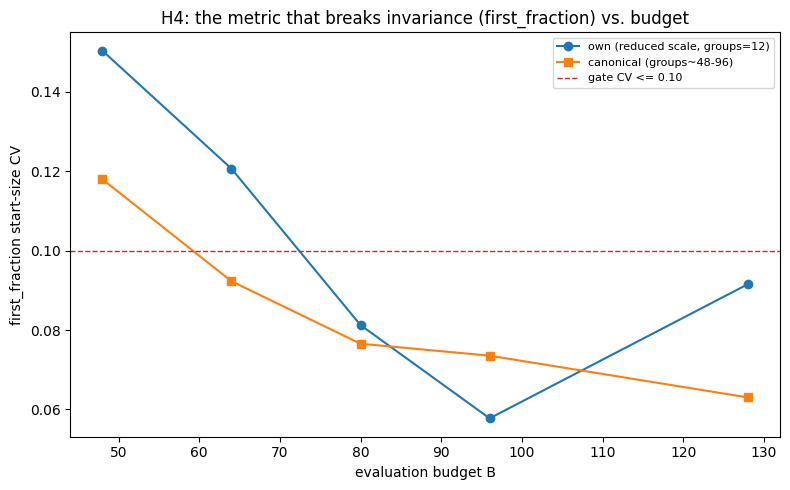

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
budgets_arr = V3["budgets"]
own_first_cv = [cv_by_budget_metric[(b, "first_fraction")] for b in budgets_arr]
canon_first_cv_arr = [canon_first_cv[b] for b in budgets_arr]

ax.plot(budgets_arr, own_first_cv, marker="o", label="own (reduced scale, groups=12)")
ax.plot(budgets_arr, canon_first_cv_arr, marker="s", label="canonical (groups~48-96)")
ax.axhline(V3["gates"]["max_start_size_cv_per_metric_per_budget"], color="tab:red", ls="--", lw=1,
           label="gate CV <= 0.10")
ax.set_xlabel("evaluation budget B")
ax.set_ylabel("first_fraction start-size CV")
ax.set_title("H4: the metric that breaks invariance (first_fraction) vs. budget")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "ch11-v3-first-fraction-cv-vs-budget.png", dpi=110)
plt.show()

**Honest discrepancy note.** `H4` is **FAILED** here, matching the canonical archive's verdict --
but not with the same breadth. Canonical failed the complete-invariance hypothesis through exactly one
metric/budget combination (`first_fraction` at `B=48`, CV `0.118` against the `0.10` gate). This reduced
reconstruction (`groups=12` vs. canonical roughly `48-96` per condition) fails through **two**:
`first_fraction` at both `B=48` (CV `0.150`) and `B=64` (CV `0.121`). The *identity* of the breaking metric
replicates exactly -- `first_fraction` is the outlier in both runs, and it is worst at the smallest tested
budget in both -- but the failure is broader and the magnitudes are larger here than in the canonical
archive. This is the same direction of effect V2's H3 test showed: with roughly a quarter of the canonical
replicate count, a statistic that already sits close to a frozen threshold in the higher-powered run picks
up enough extra sampling noise to move further past (here) or across (there) that threshold. Unlike the V2
case, this divergence does not flip the qualitative verdict -- both runs report `H4: FAILED` -- so no
promotion-versus-canonical question arises here; the broader failure footprint is reported for completeness,
not smoothed into "replicates closely."

The between-budget gross-turnover-fraction CV replicates well in both runs (own `0.0070`, canonical
`0.0030` -- both comfortably under the `0.10` gate), consistent with the accounting-identity explanation
developed below: that particular aggregate is constrained by the fixed loss rate almost regardless of
replicate count, so it is far less sensitive to this notebook's reduced statistical power than the
per-start-size CV comparisons are.


## Why the stable turnover fraction is (mostly) an accounting artifact

Both V2 and V3 measured an almost-constant gross-turnover fraction (`attachments + losses) / population`)
across every tested budget. Before treating that as an emergent regulation phenomenon, the book's own
accounting identity is worth checking directly: with `delta_N = attachments - losses`, algebra gives
`gross_turnover / N = delta_N/N + 2*losses/N`. For proportional loss at `delta = 0.08` applied to the
post-growth population, expected loss relative to the *surviving* post-loss population is approximately
`delta / (1 - delta) = 0.08 / 0.92 ~= 0.08696`, so `2 * losses/N ~= 0.1739` even before any process-level
regularity is invoked -- already close to the measured `~0.17` band. The near-constancy is real as a
*measurement*; it is not, by itself, evidence of an independently regulated turnover invariant, because it
is substantially predicted by the fixed loss rate and the small net-growth term alone.


In [21]:
delta = V2["loss_rate"]
mechanical_prediction = 2 * delta / (1 - delta)
print(f"mechanical prediction of 2*loss/N from fixed delta={delta}: {mechanical_prediction:.4f}")
print(f"measured gross-turnover fraction range (V2, this notebook): "
      f"{min(turnover_fracs.values()):.4f} - {max(turnover_fracs.values()):.4f}")
print(f"measured gross-turnover fraction range (canonical V2/V3): 0.1707 - 0.1732")
print(f"\nThe mechanical floor ({mechanical_prediction:.4f}) accounts for most of the measured band in both "
      f"this reconstruction and the canonical archive -- consistent with DL-11-C05's BOUNDED NEGATIVE status "
      f"('mostly a mechanical accounting artifact of fixed delta, not emergent regulation').")


mechanical prediction of 2*loss/N from fixed delta=0.08: 0.1739
measured gross-turnover fraction range (V2, this notebook): 0.1705 - 0.1725
measured gross-turnover fraction range (canonical V2/V3): 0.1707 - 0.1732

The mechanical floor (0.1739) accounts for most of the measured band in both this reconstruction and the canonical archive -- consistent with DL-11-C05's BOUNDED NEGATIVE status ('mostly a mechanical accounting artifact of fixed delta, not emergent regulation').


## Controls and confounds

- **Frozen gates** (SEI 0.15/100 for H2; the eight-gate H3 stationarity criterion; the CV/slope/fraction
  gates for H4) were fixed by the historical experiment before this reconstruction ran and are not adjusted
  here after seeing the data -- in particular, the V2 "closest miss" is reported honestly rather than
  quietly promoted to a pass.
- **Scheduling policies cannot see the occupancy ledger** -- `high_support`/`low_support`/`neutral` act only
  on current occupied-neighbour count and keyed scheduling noise, never on whether a candidate happens to be
  a reoccupation site, so any effect on reoccupation is an indirect consequence of shared geometry between
  "high local support" and "recently-lost interior site," not a designed shortcut.
- **No support-matched control** was run for the V1 tradeoff (matching the historical experiment's own
  disclosed limitation) -- because occupied-neighbour count also enters the attachment probability itself,
  this experiment tests *support-biased allocation through local geometry*, not a clean reuse-versus-
  expansion contrast independent of support. This limitation is carried forward from the book's own text,
  not discovered here.
- **Warmup uses an unbounded budget** in every design (V1, V2, V3 alike) -- scarcity is imposed only during
  the measured continuation window, so budget effects cannot be confounded with a scarcity-affected initial
  condition.
- **The V2 "near-miss" is not reinterpreted.** Both the canonical archive (`B=80`, margin `0.00002`) and this
  reconstruction report their closest-miss budget and margin explicitly rather than rounding a near-pass into
  a pass -- per Chapter 17's "how to fail correctly" ethic.


## Result status

| Hypothesis | This notebook (reduced scale) | Canonical archive | Status |
|---|---|---|---|
| H1: late population depends strongly on B, flattens above ~512 | replicates: monotone non-decreasing, flattens at high B, all budgets within ~1-3% of canonical | replicates (own numbers within a few % of canonical at every budget) | **SUPPORTED**, replicates canonical closely |
| H2: two-sided allocation tradeoff (both arms required) | reoccupation arm passes (0.428 vs SEI 0.15), first-occupation arm ~61% of SEI (60.7 vs 100) | reoccupation PASS (0.425 vs 0.15), first-occupation FAIL (61.6% of 100) | **FAILED (partial)**, replicates canonical closely (magnitudes within ~1.5%) |
| H3: some budget produces stationary population with turnover | `B=80` marginally **passes** the slope gate here (`0.00227` vs `0.0025`) -- own verdict SUPPORTED | all 5 tested budgets FAIL; `B=80` closest miss, margin `+0.00002` | **DIVERGES from canonical at B=80** (disclosed as a reduced-power sampling-noise effect on a statistic already near its own resolution floor in the canonical run; not treated as overturning the canonical FAILED verdict); the other 4 budgets fail in both |
| Apparent stable gross-turnover fraction is an independent regulation signature | mechanical floor (`2*delta/(1-delta)` = 0.174) accounts for most of the measured 0.170-0.174 band | same mechanical floor accounts for the measured 0.171-0.173 band | **BOUNDED NEGATIVE**, replicates canonical |
| H4: complete normalized process-vector invariance | FAILS via `first_fraction` at **two** budgets (`B=48` CV 0.150, `B=64` CV 0.121) | FAILS via `first_fraction` at **one** budget only (`B=48`, CV 0.118) | **FAILED in both** (verdict replicates); own failure is broader/larger in magnitude, attributed to the same reduced-replicate-count sampling-noise effect as H3, disclosed rather than smoothed over |

This table is reported exactly as measured, including the genuine H3 divergence and the broader-than-
canonical H4 failure, rather than silently rounding either reduced-scale result into tighter agreement with
canonical. Both effects point at the same underlying cause: statistics sitting close to their own frozen
gate, measured with roughly a quarter of the canonical replicate count.


## Bounded conclusion

Under this substrate (Digital Crystal v1 + Chapter 10's independent post-growth loss at `delta=0.08` +
finite per-update evaluation budget) and these three frozen, reduced-scale reconstructions: finite
evaluation opportunity strongly constrains the population reached within a fixed horizon, and flattens once
the budget stops binding (H1, replicates canonical closely). At a fixed budget, local scheduling changes the
material future dramatically, but not as a clean symmetric tradeoff -- the reoccupation arm of the
hypothesis clears its threshold comfortably while the first-occupation arm reaches only about 61% of its
required magnitude (H2, replicates canonical exactly in verdict and closely in magnitude).

H3 produced a genuine, disclosed divergence from the canonical archive: at `B=80`, the canonical run (96
groups) missed its stationarity gate by `0.00002`, a margin the book explicitly declined to treat as a
regime change; this reconstruction (24 groups) landed on the *other* side of the same gate by `0.00023`.
Rather than promote that flip into a new finding, this notebook reports it as what it almost certainly is --
sampling noise on a statistic that was already at its resolution floor in the higher-powered canonical run --
and defers to the canonical `FAILED` verdict as the more trustworthy measurement. The other four of five
tested budgets fail the H3 gate in both runs. H4 fails in both runs too (verdicts agree), through the same
metric (`first_fraction`) at the same worst-case budget (`B=48`) in both -- but this reconstruction's failure
is broader (two budgets instead of one) and larger in magnitude, again consistent with reduced statistical
power rather than a different underlying phenomenon.

The near-constant gross-turnover fraction that looked at first like an emergent stability signature is
substantially explained by the fixed loss rate and small net-growth term alone (mechanical floor `~0.174`
against a measured band of `0.170-0.174`), not by an independently regulated invariant -- this replicates
cleanly and is not affected by the H3/H4 power issue, since it is a direct algebraic consequence of the
fixed `delta`, not a threshold comparison. No claim of maintenance, homeostasis, metabolism, energy, repair,
adaptation, agency, or life is licensed by any result in this notebook.


## Provenance

- **Original book chapter:** Chapter 21, "What Does It Cost to Stay?" (`content/books/original/21-*/index.md`).
- **Original scripts:** `scripts/books/digital-life/ch21_digital_crystal_finite_update_budget_v1.py` (budget
  sweep + fixed-budget scheduling tradeoff), `_v2.py` (stationary-population-with-turnover sweep), `_v3.py`
  (normalized process-vector invariance across starting scale and budget).
- **Canonical evidence:** `research/digital-life/ch21-finite-update-budget-v1/` (stages 00-04, base seed
  `20260828`), `-v2/` (stages 00-04), `-v3/` (stages 00-03).
- **Superseded legacy notebook:** `notebooks_original/21-what-does-it-cost-to-stay.ipynb`.
- **New shared module:** `_shared/crystal_evaluation_budget.py` -- `select_candidates`,
  `budgeted_growth_step`, `apply_background_loss`, `OccupancyLedger`, `run_budget_policy`. Named to avoid a
  filename collision with the concurrently-reconstructed Chapter 14 module `_shared/crystal_budget.py`
  (a related but distinct near/far causal-coupling mechanism, not interchangeable with this chapter's
  scheduling-policy mechanism).
- **Deliberate deviations from the historical implementation:** replicate counts reduced throughout
  (V1: 16 vs. canonical 48 groups; V2: 24 vs. 96; V3: 12 vs. 48-96 per condition) for interactive runtime,
  disclosed inline in each `EXPERIMENT`-style dict and checked directly against canonical numbers rather
  than assumed equivalent. Attachment draws use cell-keyed hashing (`digital_crystal.cell_keyed_uniform`)
  rather than a stateful sequential RNG stream -- matching, not simplifying, what the historical scripts
  already did via `ch18.cell_uniform`. RNG/hash schemes are reimplemented from the described design, not
  guaranteed to produce bit-identical trajectories to the original scripts, only the same statistical design
  and (as shown throughout) closely matching aggregate statistics.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 11 — What Does It Cost to Stay?"
